# Restaurant Clustering

Builds the clustering outputs used by the dashboard:
- `data_output/reviews.csv`: review-level text corpus with cluster labels
- `data_output/clustering_results.csv`: restaurant-level cluster assignments with 2D coordinates


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
from umap import UMAP
import scipy.sparse as sp

from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction import text

BASE_DIR = Path("..")
KOL_PATH = BASE_DIR / "data" / "kol" / "KOL_Posts.csv"
PLACES_PATH = BASE_DIR / "_1_eda" / "data_output" / "places_api_new_results.csv"
REVIEWS_PATH = BASE_DIR / "_3_marketing" / "data_output" / "restaurant_reviews.parquet"
OUTPUT_DIR = Path("data_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
GMV_VIEW = BASE_DIR / "_5_GA_data" / "data_output" / "gmv" / "gmv_view.parquet" # New clustering to be based on this GMV data
GA_PATH = BASE_DIR / "_5_GA_data" / "data_output" / "combined_restaurant_ga.parquet" # For potential future use
RESTAURANT_CITIES = BASE_DIR / "_6_web_scraping" / "restaurant_city_scraped.csv"

kol_posts = pd.read_csv(KOL_PATH) # KOL posts
places = pd.read_csv(PLACES_PATH) # Places API results
restaurant_reviews = pd.read_parquet(REVIEWS_PATH) # Restaurant reviews
gmv_view = pd.read_parquet(GMV_VIEW) # GMV data
combined_ga = pd.read_parquet(GA_PATH) # Combined GA data for all restaurants
restaurant_cities = pd.read_csv(RESTAURANT_CITIES) # Restaurant city data

kol_posts # 923 rows × 35 columns
places # 2392 rows × 12 columns
restaurant_reviews # 9674 rows × 15 columns
gmv_view # 17319 rows × 16 columns
combined_ga # 17687 rows × 55 columns

restaurant_reviews['input_restaurant_name'].nunique() #1947
kol_posts['Restaurant Name'].nunique() # 301
kol_posts['Restaurant Code'].nunique() # 236
combined_ga['name'].nunique() # 2808 (name and id same)
gmv_view.columns

/Users/jadentyh/Desktop/IS455/Project/OPE/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Index(['year_month', 'ga_items_viewed', 'ga_items_added_to_cart',
       'ga_items_purchased', 'ga_item_revenue', 'restaurant_id', 'name',
       'monthly_gmv', 'monthly_bookings', 'yearMonth', 'gmv_per_view',
       'bookings_per_view', 'ga_add_to_cart_rate', 'view_to_purchase_rate',
       'purchase_to_cart_rate', 'revenue_per_view'],
      dtype='str')

In [2]:
# kol_posts[kol_posts['Restaurant Name'].isnull() | kol_posts['Restaurant Code'].isna()] # 59 posts with no restaurant name and code
#combined_ga['']

## 1. Build the Restaurant Text Corpus


In [3]:
# Use combined GA as main dataset for all restaurants since it contains the most restaurants

# 1. Aggregated combined ga
combined_ga_aggregated = (
    combined_ga.groupby(["restaurant_id"], as_index=False)
    .agg(
        restaurant_name=('name','first'),
        # country=('country','first'),
        # city=('city','first'),
        # review_count=('raw_text','size'),
        # avg_monthly_gmv=('avg_monthly_gmv','mean'),
        # avg_monthly_bookings=('avg_monthly_bookings','mean'),
        # avg_gmv_per_view=('avg_gmv_per_view','mean'),
        # avg_view_to_purchase=('avg_view_to_purchase','mean'),
        # avg_rev_per_view=('avg_rev_per_view','mean'),
        # avg_ga_add_to_cart_rate=('avg_ga_add_to_cart_rate','mean')
    )
)
combined_ga_aggregated # 2808 rows × 55 columns

,restaurant_id,restaurant_name
0,33,Audrey Cafe Thonglor Soi 11
1,168,Attico Cucina Italiana Radisson Blu Plaza Bangkok
2,220,The Living Room at Sheraton Grande Sukhumvit A...
3,222,Rain Tree Cafe at The Athenee Hotel
4,273,Skyline at Avani+ Riverside Bangkok Hotel
...,...,...
2803,6958,Werng Public Market at Central Chidlom (Bib Go...
2804,6962,Hide.away Cafe
2805,6964,Caveman Barbeque (Rayong)
2806,6966,Mr.Shabu Market Place Rangsit Khlong 1


In [4]:
# 2. Aggregate KOL content with ID
kol_posts = kol_posts[kol_posts['Restaurant Name'].notnull()] # Remove posts with no restaurant name and code 
#print("kol posts after dropping null restaurant names:", kol_posts.shape) # 864
kol_aggregated = (
    kol_posts.groupby("Restaurant Name", as_index=False)
    .agg(
        restaurant_id=('Restaurant Code', 'first'), # For each name, get the FIRST 'Restaurant Code' found
        kol_text=('Content', lambda s: " ".join(s.dropna().astype(str))) # Each name, JOIN ALL 'Content' into 1 text block
    )
    .rename(columns={"Restaurant Name": "restaurant_name"}) # Rename for merging later
)
print("kol aggregated shape:", kol_aggregated.shape) # 301 rows × 3 columns

kol aggregated shape: (301, 3)


In [5]:
# 3. Prepare Google Places data with ID

def edit_type(raw_types):
    if pd.isna(raw_types):
        return []
    types_list = raw_types.split(",") # Split the string into a list
    edited_types = ""
    for t in types_list:
        t = t.strip() # Remove leading/trailing whitespace
        if t in ['restaurant', 'food', 'point_of_interest', 'establishment', 'food_store']:
            continue # Skip these generic types
        if t.endswith('_restaurant'):
            edited_types += t.removesuffix('_restaurant') + " " # Standardize all restaurant types to 'restaurant'
    return edited_types

places['raw_types'] = places['raw_types'].apply(lambda x : edit_type(x))
places = (
    places[["input_string", "raw_types", "Cuisine", "city", "country"]]
    .rename(columns={"input_string": "restaurant_name"})
    .drop_duplicates(["restaurant_name"])
)
print("place text shape:", places.shape) # 2392 rows × 5 columns
places

place text shape: (2392, 5)


,restaurant_name,raw_types,Cuisine,city,country
0,Audrey Cafe Thonglor Soi 11,,Cafe,NaN,Thailand
1,Attico Cucina Italiana Radisson Blu Plaza Bangkok,italian,Italian,NaN,Thailand
2,The Living Room at Sheraton Grande Sukhumvit A...,,NaN,NaN,Thailand
3,Rain Tree Cafe at The Athenee Hotel,buffet,General,NaN,Thailand
4,Skyline at Avani+ Riverside Bangkok Hotel,buffet,General,NaN,Thailand
...,...,...,...,...,...
2387,Ryoku Cafe,,Dessert,NaN,Thailand
2388,NH Boat Lagoon Phuket Resort Staycation (Phuket),,NaN,Tambon Ko Kaeo,Thailand
2389,Krua Piam Ros,,General,Singapore,Singapore
2390,Sun's Cafe at Hotel Grand Pacific Singapore,,General,Singapore,Singapore


In [6]:
# 4. Aggregate Reviews with ID
combined_restaurant_reviews = (
    restaurant_reviews.groupby(["input_restaurant_name"])["review_text"]
    .apply(lambda s: " ".join(s.dropna().astype(str))) # Agg step, join all reviews for each rest into 1 text block
    .reset_index() # Converts index back to regular column
    .rename(columns={"input_restaurant_name": "restaurant_name"})
)
print("combined restaurant reviews shape:", combined_restaurant_reviews.shape) # 1947 rows × 2 columns

combined restaurant reviews shape: (1947, 2)


In [7]:
# 5. Final Merge on ID (The Primary Key)
# We merge on restaurant_id to ensure absolute accuracy
all_restaurants = (
    combined_ga_aggregated
    .merge(combined_restaurant_reviews, on="restaurant_name", how="left", suffixes=("", "_drop"))
    .merge(places, on="restaurant_name", how="left", suffixes=("", "_drop"))
    .merge(kol_aggregated, on="restaurant_name", how="left", suffixes=("", "_drop"))
)
print("finalised for all restaurants shape:", all_restaurants.shape) # 2808 rows × 9 columns

finalised for all restaurants shape: (2808, 9)


In [8]:
# Clean up duplicate name columns from the merge if they exist
all_restaurants = all_restaurants.drop(columns=[c for c in all_restaurants.columns if c.endswith("_drop")])

# 6. Combine Text
all_restaurants["raw_text"] = ( # Combined reviews from restaurant reviews & kol 
    all_restaurants["review_text"].fillna("").astype(str)
    + " "
    + all_restaurants["kol_text"].fillna("").astype(str)
).str.replace(r"\s+", " ", regex=True).str.strip()

#all_restaurants = all_restaurants[all_restaurants["raw_text"].str.len() > 0].copy()
all_restaurants.shape

(2808, 9)

In [9]:
# # 1. Aggregate KOL content with ID
# kol_posts = kol_posts[kol_posts['Restaurant Name'].notnull()] # Remove posts with no restaurant name and code 
# #print("kol posts after dropping null restaurant names:", kol_posts.shape) # 864
# kol_aggregated = (
#     kol_posts.groupby(["Restaurant Code", "Restaurant Name"])["Content"]
#     .apply(lambda s: " ".join(s.dropna().astype(str)))
#     .reset_index()
#     .rename(columns={"Restaurant Name": "restaurant name", "Content": "kol_text", "Restaurant Code": "restaurant_id"})
# )
# #print("kol aggregated shape:", kol_aggregated.shape) # 241 rows × 3 columns

# # 2. Prepare Google Places data with ID
# place_text = (
#     places[["input_string", "raw_types", "Cuisine", "city", "country"]]
#     .rename(columns={"input_string": "restaurant name"})
#     .drop_duplicates(["restaurant name"])
# )
# #print("place text shape:", place_text.shape) # 2392 rows × 5 columns

# # 3. Aggregate Reviews with ID
# review_text = (
#     restaurant_reviews.groupby(["input_restaurant_name"])["review_text"]
#     .apply(lambda s: " ".join(s.dropna().astype(str)))
#     .reset_index()
#     .rename(columns={"input_restaurant_name": "restaurant name"})
# )

# # 4. Final Merge on ID (The Primary Key)
# # We merge on restaurant_id to ensure absolute accuracy
# reviews = (
#     review_text
#     .merge(place_text, on="restaurant name", how="left", suffixes=("", "_drop"))
#     .merge(kol_aggregated, on="restaurant name", how="left", suffixes=("", "_drop"))
# )

# # Clean up duplicate name columns from the merge if they exist
# reviews = reviews.drop(columns=[c for c in reviews.columns if c.endswith("_drop")])

# # 5. Combine Text
# reviews["raw_text"] = (
#     reviews["review_text"].fillna("").astype(str)
#     # + " "
#     # + reviews["google_text"].fillna("").astype(str)
#     + " "
#     + reviews["kol_text"].fillna("").astype(str)
# ).str.replace(r"\s+", " ", regex=True).str.strip()

# reviews = reviews[reviews["raw_text"].str.len() > 0].copy()

# ## 6. AGGREGATE GMV DATA

# # Aggregate GMV data to the restaurant level (All-Time Average)
# gmv_agg = gmv_view.groupby('name', as_index=False).agg(
#     avg_monthly_gmv=('monthly_gmv', 'mean'),
#     avg_monthly_bookings=('monthly_bookings', 'mean'),
#     avg_bookings_per_view=('bookings_per_view', 'mean'),
#     avg_gmv_per_view=('gmv_per_view', 'mean'),
#     avg_view_to_purchase=('view_to_purchase_rate', 'mean'),
#     avg_rev_per_view=('revenue_per_view', 'mean'),
#     avg_ga_add_to_cart_rate=('ga_add_to_cart_rate', 'mean'),
#     avg_purchase_to_cart_rate=('purchase_to_cart_rate', 'mean')
# )

# # Merge GMV features into the review-level dataframe
# all_restaurants = reviews.merge(gmv_agg, left_on='restaurant name', right_on='name', how='left') # 1946
# all_restaurants = all_restaurants.drop(columns=['name']) # Drop the redundant 'name' column after merge

In [10]:
# Assume all thailand restaurants have country = Thailand
thailand_restaurants = all_restaurants[all_restaurants['country'] == 'Thailand']
thailand_restaurants

,restaurant_id,restaurant_name,review_text,raw_types,Cuisine,city,country,kol_text,raw_text
0,33,Audrey Cafe Thonglor Soi 11,What kind of cafe can’t even make an okay k...,,Cafe,NaN,Thailand,,What kind of cafe can’t even make an okay kind...
1,168,Attico Cucina Italiana Radisson Blu Plaza Bangkok,"Excellent restaurant, everything is freshly pr...",italian,Italian,NaN,Thailand,NaN,"Excellent restaurant, everything is freshly pr..."
2,220,The Living Room at Sheraton Grande Sukhumvit A...,Excellent Sunday buffet lunch. Seafood is very...,,NaN,NaN,Thailand,ขอยกให้เป็นบุฟเฟ่ต์นานาชาติที่ดี และอลังการที่...,Excellent Sunday buffet lunch. Seafood is very...
3,222,Rain Tree Cafe at The Athenee Hotel,"The food selection is diverse, with many optio...",buffet,General,NaN,Thailand,NaN,"The food selection is diverse, with many optio..."
4,273,Skyline at Avani+ Riverside Bangkok Hotel,Today we ate at the hotel. Every dish was deli...,buffet,General,NaN,Thailand,NaN,Today we ate at the hotel. Every dish was deli...
...,...,...,...,...,...,...,...,...,...
2786,6904,Bar BQ Resort Pinklao,NaN,buffet,General,NaN,Thailand,NaN,
2787,6906,Prodpraan Eatery (Hua Hin),"The taste suits Thai people, and it matches th...",,General,Tambon Cha-am,Thailand,NaN,"The taste suits Thai people, and it matches th..."
2788,6915,Prime 19 (Khao Yai),NaN,,General,หมูสี,Thailand,NaN,
2791,6918,The Small Town Story Chongqing Hotpot Bangna (...,NaN,,General,NaN,Thailand,NaN,


In [11]:
thailand_restaurants['city'].isnull().sum() # 1264
# First, perform the merge as you did
thailand_restaurants = thailand_restaurants.merge(
    restaurant_cities, 
    on='restaurant_id', 
    how='left'
)

thailand_restaurants['city'].fillna(thailand_restaurants['scraped_city'], inplace=True)
thailand_restaurants.drop(columns=['scraped_city'], inplace=True)
thailand_restaurants['city'].isnull().sum() # 8

/var/folders/4m/ldkhtyhj6xnbhp1g_8xt3by80000gn/T/ipykernel_88352/3914688363.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  thailand_restaurants['city'].fillna(thailand_restaurants['scraped_city'], inplace=True)


np.int64(1264)

In [12]:
# thailand_restaurants = all_restaurants[all_restaurants['country'] == 'Thailand'].copy() # 1500

# # Handle missing data (for restaurants in reviews but not in GA)
# gmv_cols = [
#     'avg_monthly_gmv', 'avg_monthly_bookings', 
#     'avg_gmv_per_view', 'avg_view_to_purchase', 'avg_rev_per_view'
# ]
# thailand_restaurants[gmv_cols] = thailand_restaurants[gmv_cols].fillna(0)

## 2. Clean and Vectorize Text


In [13]:
# First, combine the columns into a single text field
temp_text = (
    thailand_restaurants["restaurant_name"].fillna("").astype(str) + " " + 
    thailand_restaurants["raw_types"].fillna("").astype(str) + " " + 
    thailand_restaurants["raw_text"].fillna("").astype(str)
)

# Now, apply robust cleaning for vectorization
thailand_restaurants["name_type_review"] = (
    temp_text.str.lower()  # 1. Convert everything to lowercase
             .str.replace(r'[^\w\s]', ' ', regex=True)  # 2. Replace all non-alphanumeric characters with a space
             .str.replace(r'\s+', ' ', regex=True)  # 3. Collapse multiple spaces into a single space
             .str.strip()  # 4. Remove any leading/trailing spaces
)

In [14]:
# BLOCK 1: Review text (existing)
custom_redundant_words = [
    "restaurant", "good", "great", "place", "nice", "really", "just", "like", "bangkok"
    "point_of_interest", "establishment", "premise", "food_store", "hungryhub"
    "chicken", "beef", "pork", "rice", "sauce", "spice", "food", "taste",
    "stars"
    # # Catching common joined words from your previous output
    # "thai_restaurant", "chinese_restaurant", "japanese_restaurant", 
    # "seafood_restaurant", "asian_restaurant",
    # "fine_dining_restaurant", "italian_restaurant", "korean_restaurant"
]

# 2. Combine them with the default English stop words
#ALL_REDUNDANT_WORDS = list(text.ENGLISH_STOP_WORDS.union(custom_redundant_words))
stop_words = set(text.ENGLISH_STOP_WORDS)
stop_words.update(custom_redundant_words)

# 3. Pass the combined list to the vectorizer
tfid_name_type_review = TfidfVectorizer(
    max_features=1000,
    ngram_range=(1, 2),
    stop_words=list(stop_words), # Use the combined list here
    min_df=2,
)

name_type_review_vectors = tfid_name_type_review.fit_transform(thailand_restaurants["name_type_review"].fillna(""))
name_type_review_vectors = name_type_review_vectors.tolil() # Convert to LIL format for efficient row operations
names_vocab = tfid_name_type_review.vocabulary_ # Get the vocabulary mapping of terms to column indices

clear_labels = {0: ["buffet", ""], 1: ["cafe", "coffee", "coffee_shop"], 2: ["bar", "alcohol", "rooftop"]}
MULTIPLIER = 2
for index in range(len(clear_labels)):
    for word in clear_labels[index]:
        if word in names_vocab:
            col_idx = names_vocab[word]
            name_type_review_vectors[:, col_idx] *= MULTIPLIER
            break
        # if word.lower() in names_vocab:
        #     col_idx = names_vocab[word.lower()]
        #     name_type_review_vectors[:, col_idx] *= MULTIPLIER
        #     break
        # if word.upper() in names_vocab:
        #     col_idx = names_vocab[word.upper()]
        #     name_type_review_vectors[:, col_idx] *= MULTIPLIER
        #     break
        
name_type_review_vectors = name_type_review_vectors.tocsr()

In [15]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

name_type_review_vocab = tfid_name_type_review.get_feature_names_out()

for k in range(4,9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(name_type_review_vectors)

    # Extract the centroids (the mathematical center of each cluster)
    centroids = km.cluster_centers_
    labels = km.labels_
    cluster_counts = np.bincount(labels)
    
    print(f"\n{'='*70}")
    print(f"K = {k}")
    print(f"{'='*70}")
    
    cluster_top_terms = {}
    for c, count in enumerate(cluster_counts):
        centroid = km.cluster_centers_[c] # Get the centroid for cluster c
        global_avg = km.cluster_centers_.mean(axis=0) # Average centroid across all clusters
        diff = centroid - global_avg # Find terms that are more important in this cluster vs average
        top_indices = diff.argsort()[-15:][::-1] # Get indices of top 15 distinctive terms

        # Get the actual words and their corresponding weights
        top_words = name_type_review_vocab[top_indices]
        top_weights = centroids[c][top_indices]

        # Format them together like "word (0.123)"
        word_weight_pairs = [
            f"{word} ({weight:.3f})" 
            for word, weight in zip(top_words, top_weights)
        ]

        terms = set(name_type_review_vocab[i] for i in top_indices) # Get the actual terms for those indices, excluding any redundant words
        cluster_top_terms[c] = terms
        
        print(f"Cluster {c} has {count} restaurants: {', '.join(word_weight_pairs)}")
    
    # Check overlap: how many clusters share >50% of their top terms?
    duplicates = 0
    for i in range(k):
        for j in range(i+1, k):
            overlap = len(cluster_top_terms[i] & cluster_top_terms[j])
            total = len(cluster_top_terms[i] | cluster_top_terms[j])
            if overlap / total > 0.4:
                duplicates += 1
    
    print(f"\n  → Redundant cluster pairs (>40% term overlap): {duplicates}")
    print(f"  → {'✅ Good — clusters are distinct' if duplicates == 0 else '⚠️ Some clusters are too similar, K may be too high'}")


K = 4
Cluster 0 has 163 restaurants: buffet (0.460), shabu (0.058), hungryhub (0.061), premium (0.038), seafood (0.041), fresh (0.039), quality (0.037), variety (0.036), meat (0.031), sushi (0.027), sashimi (0.023), dishes (0.033), shrimp (0.026), japanese (0.043), value (0.025)
Cluster 1 has 75 restaurants: bar (0.798), rooftop (0.119), rooftop bar (0.085), bangkok (0.072), craft (0.031), cocktails (0.031), cocktail (0.027), sukhumvit (0.034), sky (0.028), vibes (0.025), city (0.025), cuisine (0.026), hotel (0.044), resort (0.024), phuket (0.026)
Cluster 2 has 34 restaurants: cafe (1.055), thai (0.052), atmosphere (0.056), decorated (0.026), vibe (0.029), beach (0.025), dessert (0.029), chinese (0.035), thong (0.022), white (0.021), river (0.027), sit (0.019), street (0.018), bistro (0.026), popular (0.015)
Cluster 3 has 1501 restaurants: delicious (0.074), thai (0.044), service (0.054), staff (0.046), italian (0.015), excellent (0.033), dish (0.015), price (0.023), highly (0.015), c

## 3. Cluster Reviews


In [16]:
cluster_themes = { # Ownself decide cluster labels from the printed results above
  4: "Buffet and premium dining",
  3: "Good food and service",
  2: "Cafe, coffee", 
  1: "Bar, rooftop, drinks",
  0: "Breakfast menu and hotel food",
}

In [17]:
def assign_theme_cluster_from_name(restaurant_name: str): # Assign cluster based on keywords in restaurant name as a heuristic
    for word in restaurant_name.split():
        match word.lower():
            case 'cafe':
                return 3
            case 'coffee':
                return 3
            case 'buffet':
                return 0
            case 'bar':
                return 4
            case 'rooftop':
                return 4
            case 'alcohol':
                return 4
    return None

In [18]:
# 1. Start by assigning EVERYTHING via KMeans to target 'cluster' column
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
thailand_restaurants["cluster"] = kmeans.fit_predict(name_type_review_vectors)

# # 2. Generate the manual overrides in a temporary Pandas Series (not added to df)
# manual_overrides = thailand_restaurants["restaurant name"].apply(assign_theme_cluster_from_name)

# # 3. Track the source for transparency
# thailand_restaurants["cluster_source"] = np.where(manual_overrides.notna(), "name_match", "kmeans")

# # 4. Override the 'cluster' column where manual matches exist, then ensure it's an int
# thailand_restaurants["cluster"] = manual_overrides.fillna(thailand_restaurants["cluster"]).astype(int)

# # map themes. if cluster_themes contains lists of keywords
# thailand_restaurants["theme"] = thailand_restaurants["cluster"].map(cluster_themes)

# # 5. Print diagnostics
# manual_count = int(manual_overrides.notna().sum())
# print(f"Manually assigned {manual_count} of {len(thailand_restaurants)} restaurants from restaurant names.")
# print(f"Fell back to KMeans for {len(thailand_restaurants) - manual_count} restaurants.")

# Save to CSV
thailand_restaurants.to_csv(OUTPUT_DIR / "reviews.csv", index=False)

thailand_restaurants # 1946
print(thailand_restaurants[thailand_restaurants['cluster'] == 0].shape) # Good food and service
print(thailand_restaurants[thailand_restaurants['cluster'] == 1].shape) # Cafe & Coffee
print(thailand_restaurants[thailand_restaurants['cluster'] == 2].shape) # Hotel food 
print(thailand_restaurants[thailand_restaurants['cluster'] == 3].shape) # Buffet
print(thailand_restaurants[thailand_restaurants['cluster'] == 4].shape) # Bar, rootop, drinks

(382, 18)
(52, 18)
(398, 18)
(822, 18)
(119, 18)


## 4. Build Restaurant-Level Assignments


In [19]:
reducer = UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=1.0,
    metric="cosine",
    random_state=42,
)
embeddings_2d = reducer.fit_transform(name_type_review_vectors.toarray())

if "cluster" not in thailand_restaurants.columns or "theme" not in thailand_restaurants.columns:
    thailand_restaurants["cluster"] = kmeans.fit_predict(name_type_review_vectors)
    thailand_restaurants["theme"] = thailand_restaurants["cluster"].map(cluster_themes)

review_points = thailand_restaurants.copy()
review_points["x"] = embeddings_2d[:, 0]
review_points["y"] = embeddings_2d[:, 1]

def dominant_value(series: pd.Series):
    counts = series.value_counts()
    return counts.index[0] if len(counts) else pd.NA

def dominant_share(series: pd.Series) -> float:
    counts = series.value_counts(normalize=True)
    return float(counts.iloc[0]) if len(counts) else np.nan

clustering_results = (
    review_points.groupby("restaurant_name", as_index=False)
    .agg(
        # Existing Cluster Logic
        restaurant_id=("restaurant_id", "first"),
        cluster=("cluster", dominant_value),
        theme=("theme", dominant_value),
        city=("city", "first"),
        x=("x", "mean"),
        y=("y", "mean"),
        cluster_confidence=("cluster", dominant_share),
        review_count=("raw_text", "size"),
        # # New Performance Metrics
        # avg_monthly_gmv=("avg_monthly_gmv", "mean"),
        # avg_monthly_bookings=("avg_monthly_bookings", "mean"),
        # avg_ga_add_to_cart_rate=("avg_ga_add_to_cart_rate", "mean"),
        # avg_gmv_per_view=("avg_gmv_per_view", "mean"),
        # avg_view_to_purchase=("avg_view_to_purchase", "mean"),
        # avg_rev_per_view=("avg_rev_per_view", "mean")
    )
    .sort_values(["cluster", "restaurant_name"])
    .reset_index(drop=True)
)

clustering_results.to_csv(OUTPUT_DIR / "clustering_results.csv", index=False)
clustering_results

/Users/jadentyh/Desktop/IS455/Project/OPE/venv/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


,restaurant_name,restaurant_id,cluster,theme,city,x,y,cluster_confidence,review_count
0,IGNIV Bangkok at The St.Regis Bangkok (One Mi...,5836,0,Breakfast menu and hotel food,NaN,7.612249,-4.304212,1.0,1
1,1897 Lounge at Siam Kempinski Hotel Bangkok,4720,0,Breakfast menu and hotel food,NaN,5.073131,-5.358456,1.0,1
2,1947 Kitchen at Hyatt Place Bangkok Sukhumvit 1,5908,0,Breakfast menu and hotel food,NaN,4.569710,-4.586646,1.0,1
3,212 Rooftop Bar At Ibis Styles Bangkok Ratchada,5255,0,Breakfast menu and hotel food,NaN,7.056220,-7.849867,1.0,1
4,7th Street Bar & Bistro Mega Bangna,6058,0,Breakfast menu and hotel food,Tambon Bang Kaeo,4.329980,-6.652250,1.0,1
...,...,...,...,...,...,...,...,...,...
1768,You&I Premium Suki Buffet Samyan Mitrtown,1336,4,Buffet and premium dining,NaN,2.946537,1.356934,1.0,1
1769,You&I Premium Suki Buffet Siam Center,3111,4,Buffet and premium dining,NaN,2.454492,2.762827,1.0,1
1770,You&I Premium Suki Buffet The Nine Center,1337,4,Buffet and premium dining,NaN,1.850742,1.953593,1.0,1
1771,You&I Premium Suki Buffet Zpell Future Park Ra...,1239,4,Buffet and premium dining,อำเภอธัญบุรี,1.588523,2.318020,1.0,1


## TESTING

In [20]:
thailand_restaurants['cluster'].isnull().sum()

np.int64(0)

In [21]:
#thailand_restaurants[thailand_restaurants['theme'].isnull()]
thailand_restaurants['city'].isnull().sum() #1051
thailand_restaurants['city'].nunique()

197

In [22]:
thailand_restaurants['cluster'].value_counts() #.sum() # 1491

cluster
3    822
2    398
0    382
4    119
1     52
Name: count, dtype: int64

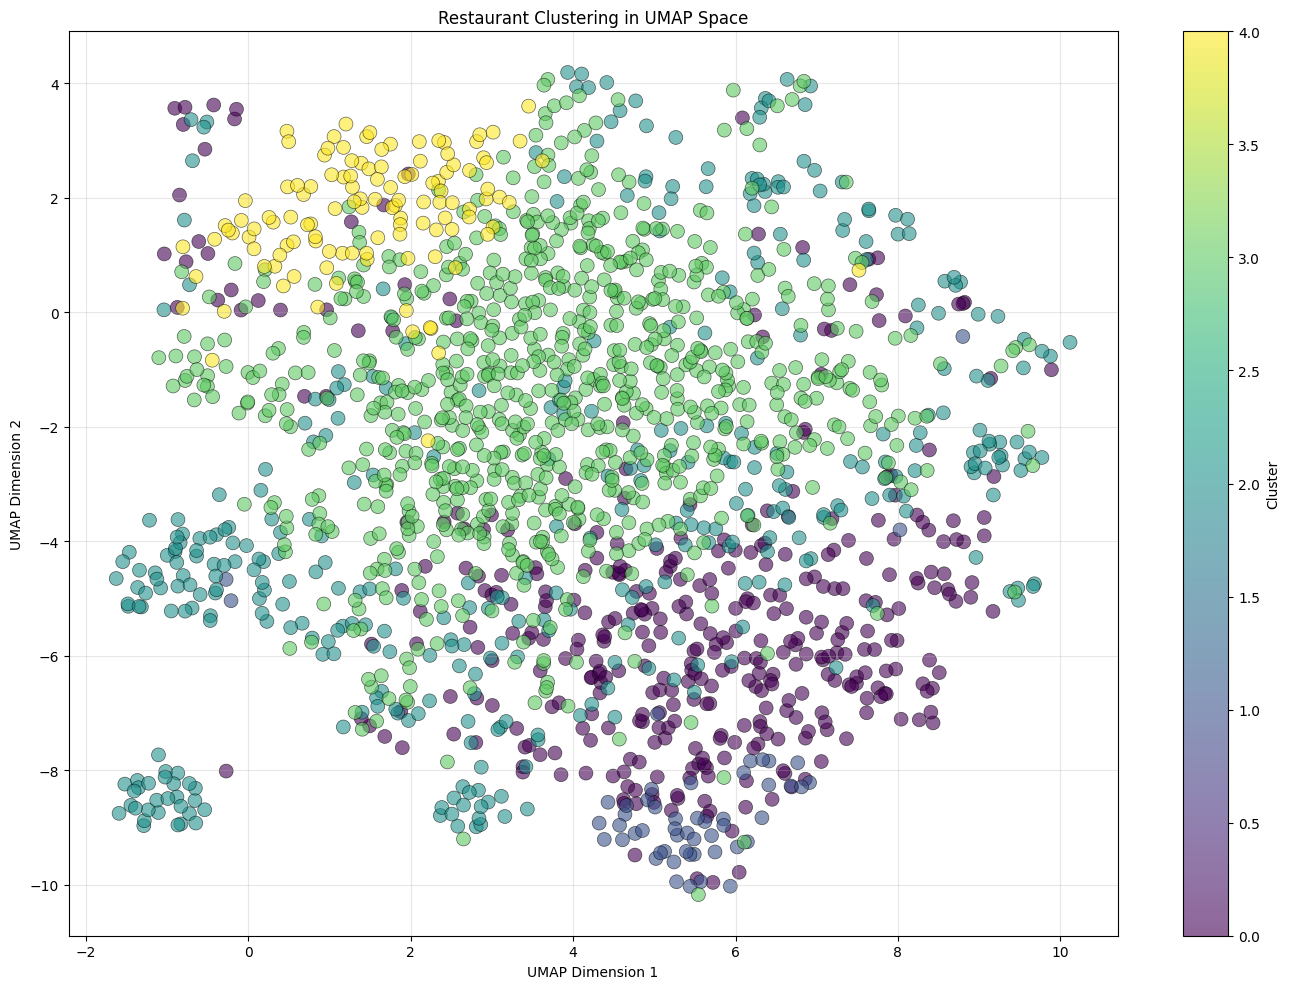

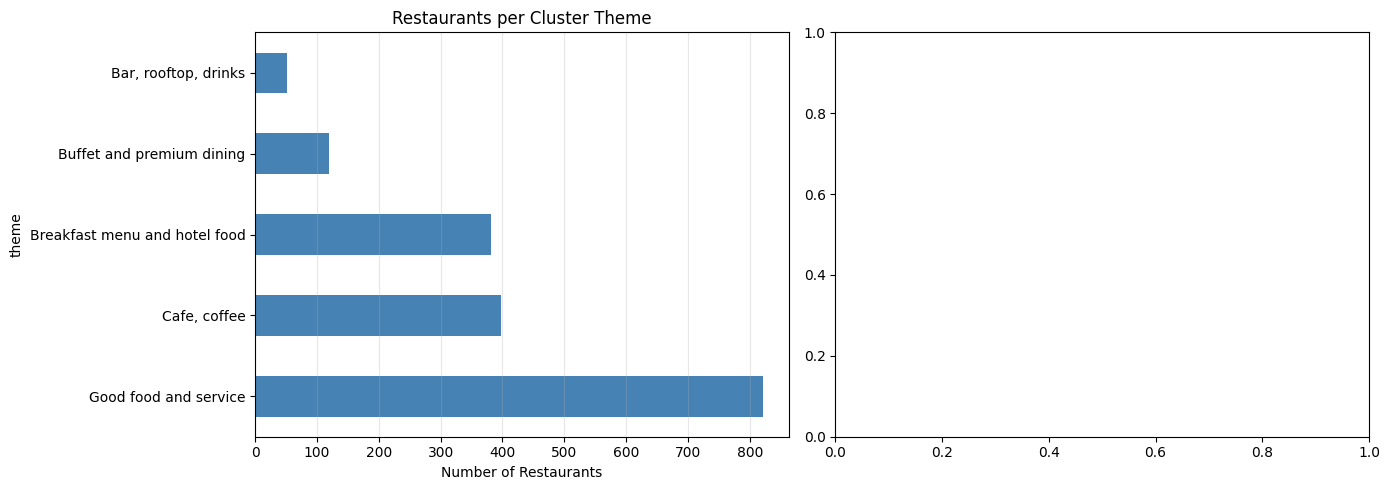


✅ VISUALIZATIONS SAVED:
  - Static UMAP plot: data_output/umap_clusters_static.png
  - Interactive UMAP plot: data_output/umap_clusters_interactive.html


In [23]:
import matplotlib.pyplot as plt
import plotly.express as px

# VISUALIZATION 1: Matplotlib UMAP Plot (Static)
plt.figure(figsize=(14, 10))
scatter = plt.scatter(
    clustering_results['x'], 
    clustering_results['y'], 
    c=clustering_results['cluster'], 
    cmap='viridis', 
    s=100, 
    alpha=0.6,
    edgecolors='black',
    linewidth=0.5
)
plt.colorbar(scatter, label='Cluster')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.title('Restaurant Clustering in UMAP Space')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "umap_clusters_static.png", dpi=300, bbox_inches='tight')
plt.show()

# VISUALIZATION 2: Plotly Interactive UMAP Plot (Hover for Details)
fig = px.scatter(
    clustering_results,
    x='x',
    y='y',
    color='theme',
    size='review_count',
    hover_name='restaurant_name',
    hover_data={
        'cluster': True,
        'theme': True,
        'review_count': True,
        'cluster_confidence': ':.2f',
        # 'avg_monthly_gmv': ':.0f',
        # 'avg_monthly_bookings': ':.0f',
        'x': False,
        'y': False
    },
    title='Interactive Restaurant Clustering (UMAP)',
    labels={
        'x': 'UMAP Dimension 1',
        'y': 'UMAP Dimension 2',
        'theme': 'Cluster Theme'
    },
    width=1000,
    height=800
)
fig.update_traces(marker=dict(line=dict(width=0.5, color='white')))
fig.write_html(OUTPUT_DIR / "umap_clusters_interactive.html")
fig.show()

# VISUALIZATION 3: Cluster Distribution Summary
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cluster counts
cluster_counts = clustering_results['theme'].value_counts()
cluster_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_xlabel('Number of Restaurants')
axes[0].set_title('Restaurants per Cluster Theme')
axes[0].grid(axis='x', alpha=0.3)

# # Plot 2: Average metrics per cluster
# cluster_metrics = clustering_results.groupby('theme').agg({
#     'avg_monthly_gmv': 'mean',
#     'avg_monthly_bookings': 'mean',
#     'cluster_confidence': 'mean'
# }).reset_index()

# cluster_metrics_normalized = cluster_metrics.copy()
# for col in ['avg_monthly_gmv', 'avg_monthly_bookings', 'cluster_confidence']:
#     cluster_metrics_normalized[col] = (cluster_metrics_normalized[col] - cluster_metrics_normalized[col].min()) / (cluster_metrics_normalized[col].max() - cluster_metrics_normalized[col].min())

# cluster_metrics_normalized.set_index('theme')[['avg_monthly_gmv', 'avg_monthly_bookings', 'cluster_confidence']].plot(
#     kind='barh', 
#     ax=axes[1], 
#     color=['#1f77b4', '#ff7f0e', '#2ca02c']
# )
# axes[1].set_xlabel('Normalized Value')
# axes[1].set_title('Average Metrics per Cluster (Normalized)')
# axes[1].legend(['Avg GMV', 'Avg Bookings', 'Cluster Confidence'], loc='lower right')
# axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "cluster_metrics_summary.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ VISUALIZATIONS SAVED:")
print(f"  - Static UMAP plot: {OUTPUT_DIR / 'umap_clusters_static.png'}")
print(f"  - Interactive UMAP plot: {OUTPUT_DIR / 'umap_clusters_interactive.html'}")
#print(f"  - Cluster metrics summary: {OUTPUT_DIR / 'cluster_metrics_summary.png'}")
